# 6. Exploitation de vos données structurées

## XPath : le langage pour naviguer dans votre base de données

Les balises que vous venez d'ajouter au texte nous permettent d'y naviguer. Le langage de navigation s'appelle [XPath](https://fr.wikipedia.org/wiki/XPath). Sélectionnez une balise, notez l'adresse XPath en haut du panneau d'édition, ouvrez le panneau `XPath`, et entrez l'adresse. Par exemple :

```
TEI/body/div/p/persName
```

S'il y a plus d'un paragraphe et plus d'une personne, vous allez découvrir que toutes les personnes sont mises en surbrillance et que vous pouvez sauter de l'une à l'autre. C'est pratique : Word ne fait pas ça.

Si l'on veut être précis, on peut utiliser des **index**. Si l'on veut la deuxième personne dans le premier paragraphe :

```
TEI/body/div/p[1]/persName[2]
```

Si l'on veut la première personne dans _chaque paragraphe_ :

```
TEI/body/div/p/persName[1]
```

Et si l'on s'en fiche d'où se trouvent les personnes exactement dans l'arborescence :

```
TEI//persName
```

Exercices :

- [ ] Ciblez un élément balisé et essayez d'y naviguer seulement avec XPath.

Il suffit de comprendre le principe. XPath est un langage informatique pour la machine, et l'IA peut vous aider à traduire, mais on ne sait pas quelle question formuler si l'on ignore la structure de votre base de données. 

## Quelques exemples pour vous motiver

La relation entre questionnement et balisage est normalement itérative : on se pose une question, on fait du balisage jusqu'à ce que l'on rencontre un imprévu, puis on raffine le questionnement et la méthode de balisage et l'on continue. Les vrais résultats arrivent tout d'un coup, en quelques secondes, à la fin d'un travail de quelques semaines. C'est par conséquent un travail un peu « à l'aveugle » dans lequel il est facile de se perdre et de se décourager. Pour vous rassurer sur le potentiel final de ce travail, je vous présente quelques exemples d'analyses « entrée de gamme » que vous pouvez faire sur votre corpus.

Cette page s'exécute entièrement dans **votre navigateur** (JupyterLite, via GitHub Pages). Chaque participant a sa propre session : votre fichier XML reste sur votre ordinateur et n'est jamais envoyé sur GitHub.

### Importer votre fichier balisé

1. Exécutez la cellule immédiatement ci-dessous (`Shift+Enter`).
2. Cliquez sur le bouton **Choisir un XML** qui apparaît sous la cellule.
3. Sélectionnez sur votre ordinateur le fichier XML que vous venez de baliser.
4. Attendez le message indiquant que le fichier est enregistré dans la session.
5. Exécutez ensuite les cellules des exemples, une par une.

Le fichier reste dans la session locale du navigateur ; il n'est pas envoyé sur GitHub.


In [1]:
%pip install -q --disable-pip-version-check beautifulsoup4 ipywidgets lxml pandas matplotlib networkx tqdm

from pathlib import Path
import sys

scripts_dir = next(
    candidate
    for candidate in (Path("scripts"), Path("../scripts"), Path("../../scripts"), Path("../../../scripts"))
    if candidate.exists()
)
sys.path.insert(0, str(scripts_dir.resolve()))

from xml_upload import show_upload

show_upload()


Note: you may need to restart the kernel to use updated packages.


## Exemple 1 : Totaux

Comptez combien de fois chaque type de balise apparaît dans votre texte.


In [2]:
from pathlib import Path
import sys

scripts_dir = next(
    candidate
    for candidate in (Path("scripts"), Path("../scripts"), Path("../../scripts"), Path("../../../scripts"))
    if candidate.exists()
)
sys.path.insert(0, str(scripts_dir.resolve()))

import importlib
import chapter_06_analyses
importlib.reload(chapter_06_analyses)
from chapter_06_analyses import load_soup, setup_scripts_path, tagged_records
from xml_upload import get_xml_path

setup_scripts_path()
XML_PATH = get_xml_path()
soup = load_soup(XML_PATH)
print(f"Analyse de : {XML_PATH.name}")

results_dic = tagged_records(soup)["tag"].value_counts()

for tag, count in results_dic.items():
    print(f"{tag}: {count}")


Analyse de : NanQiShu_bio_223_j_55_XiaoYi_WuXinZhi_clean.xml
persName: 13
placeName: 13
date: 8
note: 5
title: 5
roleName: 5
year: 5
era: 4
suffix: 2
choice: 2
corr: 2
dyn: 1
nobleTitle: 1
sic: 1


## Exemple 2 : Formes fréquentes

Quelles chaînes reviennent le plus souvent, par type de balise ? Pour un petit fichier, nous abaissons le seuil afin d'afficher les valeurs répétées au moins deux fois.


In [3]:
from chapter_06_analyses import frequent_strings_table, load_soup, setup_scripts_path
from xml_upload import get_xml_path

setup_scripts_path()
soup = load_soup(get_xml_path())

frequent_df = frequent_strings_table(soup, min_count=1)
frequent_df


,tag,value,count
0,persName,華欽,4
1,year,三年,4
2,roleName,軍主,3
3,title,南史,3
4,corr,初,2
5,date,三年,2
6,date,建元三年,2
7,era,建元,2
8,persName,尉之,2
9,placeName,利城,2


## Exemple 3 : Balises par paragraphe

Y a-t-il des paragraphes beaucoup plus denses en balisage que d'autres ?


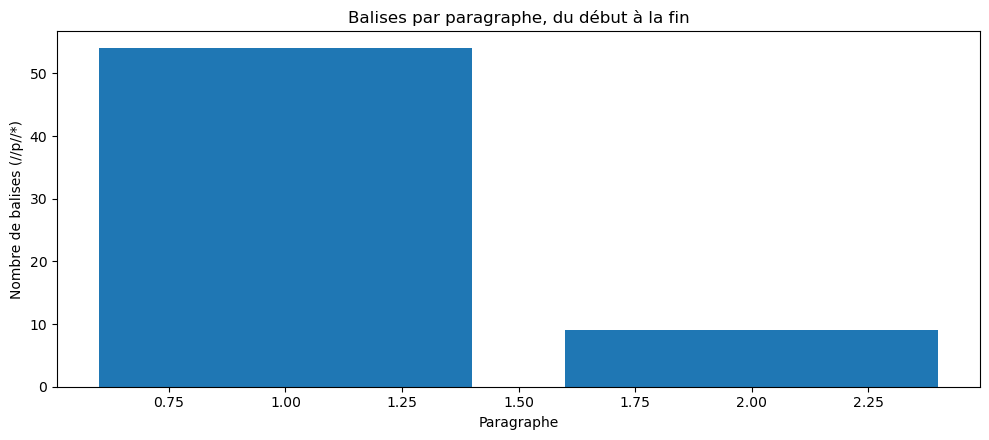

In [4]:
from chapter_06_analyses import load_soup, plot_tags_by_paragraph, setup_scripts_path
from xml_upload import get_xml_path

setup_scripts_path()
soup = load_soup(get_xml_path())

plot_tags_by_paragraph(soup)


## Exemple 4 : Réseau de cooccurrence

Quelles formes apparaissent habituellement dans le même paragraphe ? Pour un petit fichier, le seuil est abaissé afin que le réseau reste visible.


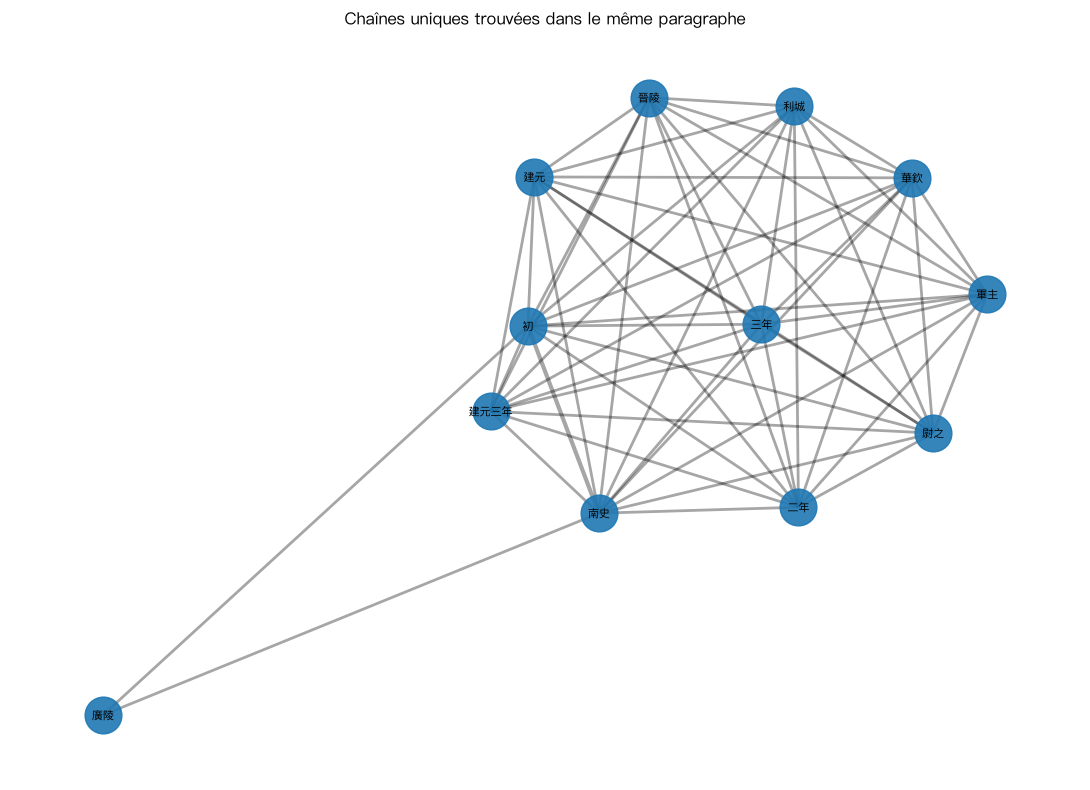

In [4]:
import importlib
import chapter_06_analyses
importlib.reload(chapter_06_analyses)
from chapter_06_analyses import load_soup, plot_cooccurrence_network, setup_scripts_path
from xml_upload import get_xml_path

setup_scripts_path()
soup = load_soup(get_xml_path())

plot_cooccurrence_network(soup, min_count=1)


## Exemple 5 : Titres cités dans le Taiping yulan

Revenons au corpus balisé au chapitre 5 : quels ouvrages sont les plus souvent cités dans l'encyclopédie _Taiping yulan_ ?


In [5]:
from chapter_06_analyses import setup_scripts_path, taiping_title_counts

setup_scripts_path()

titles_df = taiping_title_counts()
titles_df


,title,count


## Limites

Tout est possible en informatique avec une base de données ample, homogène et bien structurée, comme celles que vous allez confectionner. Les limites principales sont les suivantes :

**Vous ne savez pas extraire les données qu'il faut.** Ce n'est pas grave : parlez-en avec une IA, ou avec quelqu'un qui code. L'extraction des données est la partie la plus simple de ce travail.

**Les données n'ont pas de valeur intrinsique.** Oui, vous pouvez maintenant compter le nombre de citations dans le _Taiping yulan_, mais est-ce important ? Cela soutient-il votre argument ? Cela raconte-t-il une histoire ? Cela convainc-t-il vos collègues ? 

**Un « persName » n'est pas une personne.** Disons que dans le texte que vous avez balisé il y a quatre fois 張衡, deux fois 張平子, et plusieurs fois 衡. On peut les compter et **dédupliquer**, afin de trouver ces chiffres, mais ces trois chaînes de caractères distinctes font référence à une seule et même personne, et c'est normalement _la personne_ qui nous intéresse. 

## Exercices

- [ ] Formulez une question de recherche à laquelle l'extraction des données peut répondre.
- [ ] Convainquez-en vos camarades
